___
___
# **Zindi African Credit Scoring Challenge solution**
Vincent Schuler's solution for "Zindi African Credit Scoring Challenge".

<u>This notebook is an all-in-one solution that performs :</u>
- Reading Data;
- Feature Engineering;
- Model Training;
- Submission creation.

<u>Some information about this notebook and the solution it creates :</u>
- Running time : ~5 minutes.
- CV score : 0.914
- Public/private scores : 0.801/0.766 scores (4th place)
  
<u>Final Note :</u>
- I made a single_model solution (running very fast) that achieves 0.809/0.780 scores (3rd place) and would have won a prize.

___
___
# **Librairies**

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, roc_auc_score

import numpy as np
import pandas as pd
import os
import re
from tqdm import tqdm

from scipy.stats import mode
import random

from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import *

import xgboost as xgb
import lightgbm as lgb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = 50
pd.options.display.max_rows = 90

___
___
# **Load data**

In [2]:
# Indicate here where to find the data
filedir = "/kaggle/input/zindi-african/african-credit-scoring-challenge20241203-14702-1yayxml/"

# Loading the train dataset
train = pd.read_csv(filedir + 'Train.csv')
test  = pd.read_csv(filedir + 'Test.csv')

# Display the first few rows of the datasets and their shape
display("Train", train.head(), train.shape, "Test", test.head(), test.shape)

'Train'

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
0,ID_266671248032267278,266671,Kenya,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0
1,ID_248919228515267278,248919,Kenya,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0
2,ID_308486370501251804,308486,Kenya,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0
3,ID_266004285009267278,266004,Kenya,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0
4,ID_253803305312267278,253803,Kenya,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0


(68654, 16)

'Test'

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid
0,ID_269404226088267278,269404,Kenya,226088,267278,Type_1,1919.0,1989.0,2022-07-27,2022-08-03,7,Repeat Loan,575.7,0.300000,597.0
1,ID_255356300042267278,255356,Kenya,300042,267278,Type_1,2138.0,2153.0,2022-11-16,2022-11-23,7,Repeat Loan,0.0,0.000000,0.0
2,ID_257026243764267278,257026,Kenya,243764,267278,Type_1,8254.0,8304.0,2022-08-24,2022-08-31,7,Repeat Loan,207.0,0.025079,208.0
3,ID_264617299409267278,264617,Kenya,299409,267278,Type_1,3379.0,3379.0,2022-11-15,2022-11-22,7,Repeat Loan,1013.7,0.300000,1014.0
4,ID_247613296713267278,247613,Kenya,296713,267278,Type_1,120.0,120.0,2022-11-10,2022-11-17,7,Repeat Loan,36.0,0.300000,36.0


(18594, 15)

In [3]:
def convert_date(df) :
    for k in ["disbursement_date", "due_date"]:
        df[k] = pd.to_datetime(df[k])
        
    return df

train = convert_date(train)
test  = convert_date(test)

___
___
# **Create a dataset with train + test data**

In [4]:
df = pd.concat([train, test]).sort_values(by = ['customer_id', 'disbursement_date', 'due_date']).reset_index(drop=True)

print(df.shape)
df.head(1)

(87248, 16)


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
0,ID_145124016245684,145,Kenya,124016,245684,Type_11,14500.0,15738.0,2022-03-09,2022-04-08,30,Repeat Loan,10000.0,0.689655,10854.0,0.0


___
___
# **Feature Engineering**

### **Extract date information**

In [5]:
period_mapping = {'2021-10': 0,
                 '2021-11': 1,
                 '2021-12': 2,
                 '2022-01': 3,
                 '2022-02': 4,
                 '2022-03': 5,
                 '2022-04': 6,
                 '2022-05': 7,
                 '2022-06': 8,
                 '2022-07': 9,
                 '2022-08': 10,
                 '2022-09': 11,
                 '2022-10': 12,
                 '2022-11': 13,
                 '2022-12': 14,
                 '2023-01': 15,
                 '2023-02': 16,
                 '2023-03': 17,
                 '2023-04': 18,
                 '2023-05': 19,
                 '2023-06': 20,
                 '2023-07': 21,
                 '2023-08': 22,
                 '2023-09': 23,
                 '2023-10': 24,
                 '2023-11': 25,
                 '2023-12': 26,
                 '2024-01': 27,
                 '2024-02': 28,
                 '2024-03': 29,
                 '2024-04': 30,
                 '2024-05': 31,
                 '2024-06': 32,
                 '2024-07': 33,
                 '2024-08': 34,
                 '2024-09': 35,
                 '2024-10': 36,
                 '2024-11': 37}

In [6]:
date_cols = ['disbursement_date', 'due_date']

# Extract date information
for k in date_cols :
    df[f'year_{k}']  = df[k].dt.year
    df[f'month_{k}'] = df[k].dt.month
    df[f'day_{k}']   = df[k].dt.day
    df[f'dayofweek_{k}'] = df[k].dt.dayofweek  # 0=Monday, 6=Sunday
    # Map period
    df[f'{k}_period'] = df[k].astype(str).apply(lambda x : x[:7]).map(period_mapping)


print(df.shape)
df.head(1)

(87248, 26)


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target,year_disbursement_date,month_disbursement_date,day_disbursement_date,dayofweek_disbursement_date,disbursement_date_period,year_due_date,month_due_date,day_due_date,dayofweek_due_date,due_date_period
0,ID_145124016245684,145,Kenya,124016,245684,Type_11,14500.0,15738.0,2022-03-09,2022-04-08,30,Repeat Loan,10000.0,0.689655,10854.0,0.0,2022,3,9,2,5,2022,4,8,4,6.0


### **Add economic data**

In [7]:
eco = pd.read_csv(filedir + 'economic_indicators.csv')

# Melt the df
eco = pd.melt(eco, id_vars=['Country', 'Indicator'], var_name='year', value_name='value')

# Sort
eco = eco.sort_values(by = ['Country', 'year', 'Indicator']).reset_index(drop=True)

# Rename
eco['year'] = eco['year'].apply(lambda x : str(x[2:])).astype(int)

# Rename indicators
freq_encoding = {k:i for i, k in enumerate(eco['Indicator'].value_counts().index)}
eco['city_freq_encoded'] = eco['Indicator'].map(freq_encoding)

# Pivot
eco = eco.pivot_table(index=['Country', 'year'], columns='city_freq_encoded', values='value').reset_index()

# Rename
eco.columns = ['country_id', 'year_disbursement_date'] + [f"Economy_{x}" for x in eco.columns[2:]]

# Show
print(eco.shape)
eco.head()

(69, 11)


,country_id,year_disbursement_date,Economy_0,Economy_1,Economy_2,Economy_3,Economy_4,Economy_5,Economy_6,Economy_7,Economy_8
0,Cote d'Ivoire,2001,1348.0,NaN,34.298397,4.361529,NaN,NaN,732.397693,NaN,5.199
1,Cote d'Ivoire,2002,1348.0,NaN,37.848716,3.077265,NaN,NaN,693.713226,NaN,5.516
2,Cote d'Ivoire,2003,1348.0,NaN,32.501441,3.296807,NaN,NaN,579.897426,NaN,5.858
3,Cote d'Ivoire,2004,1348.0,NaN,24.930573,1.457988,NaN,NaN,527.338032,NaN,5.930
4,Cote d'Ivoire,2005,1348.0,7.6075,25.391257,3.885830,-0.558333,7.049167,527.258363,5.763991,6.041


In [8]:
# Join
df = pd.merge(df, eco, how='left', on = ["country_id", "year_disbursement_date"])

print(df.shape)
df.head(1)

(87248, 35)


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target,year_disbursement_date,month_disbursement_date,day_disbursement_date,dayofweek_disbursement_date,disbursement_date_period,year_due_date,month_due_date,day_due_date,dayofweek_due_date,due_date_period,Economy_0,Economy_1,Economy_2,Economy_3,Economy_4,Economy_5,Economy_6,Economy_7,Economy_8
0,ID_145124016245684,145,Kenya,124016,245684,Type_11,14500.0,15738.0,2022-03-09,2022-04-08,30,Repeat Loan,10000.0,0.689655,10854.0,0.0,2022,3,9,2,5,2022,4,8,4,6.0,NaN,7.145176,NaN,7.659863,5.190665,12.335841,117.865989,5.968447,5.805


### **Simplify loan_id**

In [9]:
%%time

# Arrange the complicated loan_id to a number representing : this is the 1st loan of the customer, this is the 2nd, etc
df['nth_loan_id'] = df.groupby('customer_id')['tbl_loan_id'].transform(lambda x: pd.factorize(x)[0]) + 1

# Show values
df['nth_loan_id'].value_counts().sort_index()

CPU times: user 1.13 s, sys: 40.6 ms, total: 1.17 s
Wall time: 1.14 s


nth_loan_id
1      8003
2      6200
3      5362
4      4828
5      4399
       ... 
248       1
249       1
250       1
251       1
252       1
Name: count, Length: 252, dtype: int64

### **Info about lenders, types of loans ...**

In [10]:
# Number of loans rows
df['loan_rows'] = df.groupby(['customer_id', 'nth_loan_id'])['customer_id'].transform('count')

# Number of unique lenders_id for the loan
df["count_lenders_for_this_loan"] = df.groupby(['customer_id', 'nth_loan_id'])['lender_id'].transform("nunique")

# Mean of nth_loans
df['mean_nth_loans'] = df.groupby('customer_id')['nth_loan_id'].transform('mean')

# Info about loans by a lender
df["n_loan_by_this_lender"]   = df.groupby(['customer_id', 'lender_id'])['customer_id'].transform('count')
df["nth_loan_by_this_lender"] = df.groupby(['customer_id', 'lender_id'])['customer_id'].transform('cumcount')

# Info about loans by a type of loan
df["n_loan_by_this_type"]   = df.groupby(['customer_id', 'loan_type'])['customer_id'].transform('count')
df["nth_loan_by_this_type"] = df.groupby(['customer_id', 'loan_type'])['customer_id'].transform('cumcount')

# Info about loans by a type of loan
df["n_loan_newrepeat"]   = df.groupby(['customer_id', 'New_versus_Repeat'])['customer_id'].transform('count')
df["nth_loan_newrepeat"] = df.groupby(['customer_id', 'New_versus_Repeat'])['customer_id'].transform('cumcount')

# Info about loans by a lender for a type of loan
df["n_loan_by_this_lender_and_type"]   = df.groupby(['customer_id', 'lender_id', 'loan_type'])['customer_id'].transform('count')
df["nth_loan_by_this_lender_and_type"] = df.groupby(['customer_id', 'lender_id', 'loan_type'])['customer_id'].transform('cumcount')

# Sum of Lender_portion_Funded	
df["sum_lender_portions"] = df.groupby(['customer_id', 'nth_loan_id'])["Lender_portion_Funded"].transform('sum')

# Info about loans by a lender for a type of loan
df["n_loan_by_this_lender_and_newrepeat"]   = df.groupby(['customer_id', 'lender_id', 'New_versus_Repeat'])['customer_id'].transform('count')
df["nth_loan_by_this_lender_and_newrepeat"] = df.groupby(['customer_id', 'lender_id', 'New_versus_Repeat'])['customer_id'].transform('cumcount')

### **Create columns**

In [11]:
# Interest rate
df['interest_rate'] = (df['Total_Amount_to_Repay'] - df['Total_Amount']) / df['Total_Amount'] * 100
df['interest_rate_lender'] = (df['Lender_portion_to_be_repaid'] - df['Amount_Funded_By_Lender']) / df['Lender_portion_to_be_repaid'] * 100
df['interest_rate_ratio'] = df['interest_rate_lender'] / df['interest_rate']

# Amount = 0 ?
df['flag_null_amount_by_lender'] = (df['Amount_Funded_By_Lender'] == 0).astype(int)

# Debt per day
df["debt_per_day"] = (df['Total_Amount_to_Repay'] - df['Total_Amount']) / df['duration']
df["debt_per_day_lender"] = (df['Lender_portion_to_be_repaid'] - df['Amount_Funded_By_Lender']) / df['duration']

# Real portions
df['Lender_portion_to_be_repaid_real'] = df['Lender_portion_to_be_repaid'] / df['Total_Amount_to_Repay']
df['real_amount_due_to_lender'] = df[["Amount_Funded_By_Lender", "Lender_portion_to_be_repaid"]].max(axis=1)
df['anomaly_less_is_due'] = (df['Total_Amount'] > df['Total_Amount_to_Repay']).astype(int)
df['anomaly_less_is_due_to_lender'] = (df['Amount_Funded_By_Lender'] > df['real_amount_due_to_lender']).astype(int)

# Ratios
df['fees_per_day'] = ((df['Total_Amount_to_Repay'] - df['Total_Amount']) / df['duration']).clip(0, None)
df['fees_per_day_due_to_lender'] = ((df['real_amount_due_to_lender'] - df['Amount_Funded_By_Lender']) / df['duration']).clip(0, None)
df['proportion_per_day'] = (df['Lender_portion_Funded']) / df['duration']
df['fees_ratio'] = (df['fees_per_day_due_to_lender'] / df['fees_per_day']).clip(0, 1)

# Create financial ratios and transformations
df['log_Total_Amount'] = np.log1p(df['Total_Amount'])

# Nth rows
df['nth_rows'] = df.groupby(["customer_id"])['ID'].transform("count")
df['prop_nth_rows'] = (df.groupby(["customer_id"])['ID'].transform("cumcount")+1) / df['nth_rows']
df['prop_nth_rows_type'] = (df.groupby(["customer_id", 'loan_type'])['ID'].transform("cumcount")+1) / df.groupby(["customer_id", 'loan_type'])['ID'].transform("count")

# Modulo
df['duration_modulo_7'] = df['duration'] % 7
df['duration_modulo_30'] = df['duration'] % 30

print(df.shape)
df.head(2)

(87248, 70)


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target,year_disbursement_date,month_disbursement_date,day_disbursement_date,dayofweek_disbursement_date,disbursement_date_period,year_due_date,month_due_date,day_due_date,dayofweek_due_date,...,n_loan_by_this_lender_and_type,nth_loan_by_this_lender_and_type,sum_lender_portions,n_loan_by_this_lender_and_newrepeat,nth_loan_by_this_lender_and_newrepeat,interest_rate,interest_rate_lender,interest_rate_ratio,flag_null_amount_by_lender,debt_per_day,debt_per_day_lender,Lender_portion_to_be_repaid_real,real_amount_due_to_lender,anomaly_less_is_due,anomaly_less_is_due_to_lender,fees_per_day,fees_per_day_due_to_lender,proportion_per_day,fees_ratio,log_Total_Amount,nth_rows,prop_nth_rows,prop_nth_rows_type,duration_modulo_7,duration_modulo_30
0,ID_145124016245684,145,Kenya,124016,245684,Type_11,14500.0,15738.0,2022-03-09,2022-04-08,30,Repeat Loan,10000.0,0.689655,10854.0,0.0,2022,3,9,2,5,2022,4,8,4,...,1,0,0.689655,1,0,8.537931,7.868067,0.921543,0,41.266667,28.466667,0.689668,10854.0,0,0,41.266667,28.466667,0.022989,0.689822,9.581973,1,1.0,1.0,2,0
1,ID_161361065267277,161,Kenya,361065,267277,Type_9,11025.0,11686.5,2024-01-15,2024-02-14,30,Repeat Loan,4097.0,0.371610,4343.0,0.0,2024,1,15,0,27,2024,2,14,2,...,1,0,0.371610,1,0,6.000000,5.664287,0.944048,0,22.050000,8.200000,0.371625,4343.0,0,0,22.050000,8.200000,0.012387,0.371882,9.308011,1,1.0,1.0,2,0


In [12]:
def get_rate_bins(x):
    rates = [-1, 0, 0.65, 1, 1.5, 2, 2.4, 2.6, 3, 4.5, 6.4]
    for i, (start, end) in enumerate(zip(rates[:-1], rates[1:])) :
        if start <= x <= end : return i
    return len(rates)-1

df['interest_rate_bins'] = df['interest_rate'].clip(0, 8).apply(get_rate_bins)
df['interest_rate_bins'].value_counts().sort_index()

interest_rate_bins
0     29387
1      7496
2      6353
3      6572
4      4529
5      3292
6      2115
7      4075
8     16757
9      2448
10     4224
Name: count, dtype: int64

### **Information about loans who have failed in the past or future**

In [13]:
# Nombre de lignes identiques
df["n_same_loans"]     = df.groupby(["customer_id", "loan_type", 'New_versus_Repeat', "Total_Amount", "disbursement_date", "due_date"])["ID"].transform("count") - 1
df["n_recurent_loans_so_far"] = df.groupby(["customer_id", "loan_type", 'New_versus_Repeat', "Total_Amount"])["ID"].transform("cumcount")
df["n_recurent_loans"] = df.groupby(["customer_id", "loan_type", 'New_versus_Repeat', "Total_Amount"])["ID"].transform("count")
df["n_same_loans"].value_counts()

n_same_loans
0    77589
1     9192
2      294
3       76
4       45
9       20
5       18
6       14
Name: count, dtype: int64

In [14]:
# Interest rate feature
df["mean_interest_rate_over_loan_id"]    = df.groupby(['customer_id', 'nth_loan_id'])['interest_rate'].transform('mean')
df["min_interest_rate_over_loan_id"]     = df.groupby(['customer_id', 'nth_loan_id'])['interest_rate'].transform(min)
df["nunique_interest_rate_over_loan_id"] = df.groupby(['customer_id', 'nth_loan_id'])['interest_rate'].transform('nunique')
df["ratio_mean_interest_rate_over_loan_id"] = df['interest_rate'] / df["mean_interest_rate_over_loan_id"]
df["ratio_min_interest_rate_over_loan_id"]  = df['interest_rate'] / df["min_interest_rate_over_loan_id"]

In [15]:
cols = ['customer_id', 'loan_type', 'New_versus_Repeat', 'Total_Amount', 'duration']

df["nunique_similar_loans"] = df.groupby(cols)["nth_loan_id"].transform('nunique') - 1 # difference to avoid biais by counting the current row
df["count_similar_loans"] = df.groupby(cols)["nth_loan_id"].transform('count') - 1 # difference to avoid biaias by counting the current row
df["sum_targets_similar_loans"] = df.groupby(cols)["target"].transform('sum') - df['target'] # difference to avoid biaias by counting the current row
df["mean_targets_similar_loans"] = df["sum_targets_similar_loans"] / df["count_similar_loans"]

# Mean of nth_loan_id
df["mean_nth_loan_similar_loans"] = df.groupby(cols)["nth_loan_id"].transform('mean')
df['nth_loan_diff'] = (df['nth_loan_id'] - df["mean_nth_loan_similar_loans"])

# Identify augmentation of interest rate for similar loan, which is often related to a previous default
df["mean_interest_rate_similar_loans"] = df.groupby(cols)["interest_rate"].transform('mean')
df['interest_rate_diff'] = (df['interest_rate'] - df["mean_interest_rate_similar_loans"])
df['reliable_loan'] = ((df["nunique_similar_loans"] > 1) & (df['interest_rate_diff'] < 0.1) & (df["sum_targets_similar_loans"]==0)).astype(int)
df['suspicious_loan'] = ((df['interest_rate_diff'] > 0.5) & (df["sum_targets_similar_loans"]>0)).astype(int)

# Mean of interest_rate lender
df["mean_interest_rate_lender_similar_loans"] = df.groupby(cols + ['lender_id'])["interest_rate_lender"].transform('mean')
df['interest_rate_lender_diff'] = (df['interest_rate_lender'] - df["mean_interest_rate_lender_similar_loans"])

In [16]:
# When reliable_loan=1, almost all targets are equal to 0 !
df[['reliable_loan', 'target']].value_counts().to_frame().sort_index()

count
reliable_loan target       
0             0.0     63563
              1.0      1255
1             0.0      3833
              1.0         3

In [17]:
# When suspicious_loan=1, almost all targets are equal to 1 !
df[['suspicious_loan', 'target']].value_counts().to_frame().sort_index()

count
suspicious_loan target       
0               0.0     67390
                1.0      1221
1               0.0         6
                1.0        37

___
## **Create customer-wise columns**

In [18]:
types_mapping = {'Type_1': 4,
                 'Type_2': 1,
                 'Type_3': 3,
                 'Type_4': 2,
                 'Type_5': 3,
                 'Type_6': 3,
                 'Type_7': 3,
                 'Type_8': 3,
                 'Type_9': 2,
                 'Type_10': 4,
                 'Type_11': 3,
                 'Type_12': 3,
                 'Type_13': 6,
                 'Type_14': 1,
                 'Type_15': 1,
                 'Type_16': 6,
                 'Type_17': 6,
                 'Type_18': 3,
                 'Type_19': 6,
                 'Type_20': 1,
                 'Type_21': 6,
                 'Type_22': 6,
                 'Type_23': 1,
                 'Type_24': 6,
                }

df['loan_type_dangerous'] = df['loan_type'].map(types_mapping)
df.groupby(['loan_type_dangerous']).agg({'target':['count', 'mean']}).reset_index().sort_index()

loan_type_dangerous target          
                       count      mean
0                   1    208  0.668269
1                   2   1440  0.130556
2                   3   4761  0.083806
3                   4  62189  0.008555
4                   6     56  0.000000

In [19]:
types_mapping = {'Type_1': 1,
                 'Type_2': 2,
                 'Type_3': 3,
                 'Type_4': 4,
                 'Type_5': 5,
                 'Type_6': 6,
                 'Type_7': 7,
                 'Type_8': 9,
                 'Type_9': 9,
                 'Type_10': 10,
                 'Type_11': 11,
                 'Type_12': 11,
                 'Type_13': 11,
                 'Type_14': 12,
                 'Type_15': 13,
                 'Type_16': 13,
                 'Type_17': 13,
                 'Type_18': 13,
                 'Type_19': 13,
                 'Type_20': 13,
                 'Type_21': 13,
                 'Type_22': 13,
                 'Type_23': 13,
                 'Type_24': 13,
                }

df['loan_type_simple'] = df['loan_type'].map(types_mapping)
df[['loan_type_simple', 'loan_type']].value_counts().sort_index()

loan_type_simple  loan_type
1                 Type_1       75341
2                 Type_2         528
3                 Type_3        3039
4                 Type_4        1488
5                 Type_5        1819
6                 Type_6         455
7                 Type_7        3382
9                 Type_8          37
                  Type_9         247
10                Type_10        562
11                Type_11         56
                  Type_12         26
                  Type_13         12
12                Type_14        116
13                Type_15          5
                  Type_16         12
                  Type_17         26
                  Type_18         42
                  Type_19          4
                  Type_20         14
                  Type_21          4
                  Type_22          2
                  Type_23         24
                  Type_24          7
Name: count, dtype: int64

In [20]:
%%time

dict_agg = {'tbl_loan_id' : ['count', 'nunique'],
            'country_id' : ['nunique'],
            'reliable_loan' : ['mean'],
            'lender_id' : ['nunique'],
            'nth_loan_id' : ['nunique', 'max'],
            'loan_type' : ['nunique'],
            'loan_type_simple' : ['nunique'],
            'New_versus_Repeat' : ['nunique'],
            'duration' : ['min', 'mean', 'max', 'std'],
            'flag_null_amount_by_lender' : ['mean'],
            'interest_rate' : ['min', 'mean', 'max', 'std'],
            'fees_per_day' : ['min', 'mean', 'max', 'std'],
            'year_due_date' : ['nunique'],
            'month_due_date' : ['nunique'],
            'year_disbursement_date' : ['nunique'],
            'month_disbursement_date' : ['nunique'],
           }

# Process
for col, agg_list in dict_agg.items() :
    for calcul in agg_list:
        df[f"customer_{col}_{calcul}"] = df.groupby(['customer_id'])[col].transform(calcul)
    
# Show
print(df.shape)
df.head()

(87248, 120)
CPU times: user 119 ms, sys: 7.91 ms, total: 127 ms
Wall time: 129 ms


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target,year_disbursement_date,month_disbursement_date,day_disbursement_date,dayofweek_disbursement_date,disbursement_date_period,year_due_date,month_due_date,day_due_date,dayofweek_due_date,...,customer_country_id_nunique,customer_reliable_loan_mean,customer_lender_id_nunique,customer_nth_loan_id_nunique,customer_nth_loan_id_max,customer_loan_type_nunique,customer_loan_type_simple_nunique,customer_New_versus_Repeat_nunique,customer_duration_min,customer_duration_mean,customer_duration_max,customer_duration_std,customer_flag_null_amount_by_lender_mean,customer_interest_rate_min,customer_interest_rate_mean,customer_interest_rate_max,customer_interest_rate_std,customer_fees_per_day_min,customer_fees_per_day_mean,customer_fees_per_day_max,customer_fees_per_day_std,customer_year_due_date_nunique,customer_month_due_date_nunique,customer_year_disbursement_date_nunique,customer_month_disbursement_date_nunique
0,ID_145124016245684,145,Kenya,124016,245684,Type_11,14500.0,15738.0,2022-03-09,2022-04-08,30,Repeat Loan,10000.0,0.689655,10854.0,0.0,2022,3,9,2,5,2022,4,8,4,...,1,0.0,1,1,1,1,1,1,30,30.0,30,NaN,0.0,8.537931,8.537931,8.537931,NaN,41.266667,41.266667,41.266667,NaN,1,1,1,1
1,ID_161361065267277,161,Kenya,361065,267277,Type_9,11025.0,11686.5,2024-01-15,2024-02-14,30,Repeat Loan,4097.0,0.371610,4343.0,0.0,2024,1,15,0,27,2024,2,14,2,...,1,0.0,1,1,1,1,1,1,30,30.0,30,NaN,0.0,6.000000,6.000000,6.000000,NaN,22.050000,22.050000,22.050000,NaN,1,1,1,1
2,ID_166124634245684,166,Kenya,124634,245684,Type_11,5881.0,6914.0,2022-03-11,2022-04-10,30,Repeat Loan,5881.0,1.000000,6914.0,0.0,2022,3,11,4,5,2022,4,10,6,...,1,0.0,1,1,1,1,1,1,30,30.0,30,NaN,0.0,17.565040,17.565040,17.565040,NaN,34.433333,34.433333,34.433333,NaN,1,1,1,1
3,ID_1487125800245684,1487,Kenya,125800,245684,Type_11,7000.0,7850.0,2022-03-14,2022-04-13,30,Repeat Loan,7000.0,1.000000,7850.0,0.0,2022,3,14,0,5,2022,4,13,2,...,1,0.0,1,1,1,1,1,1,30,30.0,30,NaN,0.0,12.142857,12.142857,12.142857,NaN,28.333333,28.333333,28.333333,NaN,1,1,1,1
4,ID_4534122904245684,4534,Kenya,122904,245684,Type_11,9565.0,10672.0,2022-03-07,2022-04-06,30,Repeat Loan,9565.0,1.000000,10672.0,0.0,2022,3,7,0,5,2022,4,6,2,...,1,0.0,2,2,2,1,1,1,30,30.0,30,0.0,0.0,7.001109,9.287277,11.573445,3.233129,36.900000,65.783333,94.666667,40.847202,2,2,2,2


In [21]:
# Fill NaN in target
df['target_filled'] = df['target'].fillna(2)

dummies_cols = ['country_id',
                'nth_loan_id',
                'lender_id',
                'loan_type',
                'New_versus_Repeat',
                'year_due_date', 'month_due_date', 'year_disbursement_date', 'month_disbursement_date',
                'interest_rate_bins',
                'flag_null_amount_by_lender',
                'target_filled',
               ]

for k in tqdm(dummies_cols, total=len(dummies_cols)) :

    # Value_counts
    a = df[['customer_id', k]].value_counts().reset_index()
    
    # Pivot
    a = a.pivot(index="customer_id", columns=k, values="count").reset_index().fillna(0)
    
    # Column renaming
    a.columns = [f"other_rows_with_{k}_equal_to_{col}" if col not in ['customer_id', k] else col for col in a.columns]

    # Merge
    df = pd.merge(df, a, on=['customer_id'], how='left')

    # Add a correction to avoid leaks
    for value in df[k].unique():
        mask = (df[k] == value)
        df.loc[mask, f"other_rows_with_{k}_equal_to_{value}"] -= 1 # we must NOT count the actuel rows in the count
    

print(df.shape)
df.head(1)

100%|██████████| 12/12 [00:03<00:00,  3.19it/s]

(87248, 458)


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target,year_disbursement_date,month_disbursement_date,day_disbursement_date,dayofweek_disbursement_date,disbursement_date_period,year_due_date,month_due_date,day_due_date,dayofweek_due_date,...,other_rows_with_month_disbursement_date_equal_to_4,other_rows_with_month_disbursement_date_equal_to_5,other_rows_with_month_disbursement_date_equal_to_6,other_rows_with_month_disbursement_date_equal_to_7,other_rows_with_month_disbursement_date_equal_to_8,other_rows_with_month_disbursement_date_equal_to_9,other_rows_with_month_disbursement_date_equal_to_10,other_rows_with_month_disbursement_date_equal_to_11,other_rows_with_month_disbursement_date_equal_to_12,other_rows_with_interest_rate_bins_equal_to_0,other_rows_with_interest_rate_bins_equal_to_1,other_rows_with_interest_rate_bins_equal_to_2,other_rows_with_interest_rate_bins_equal_to_3,other_rows_with_interest_rate_bins_equal_to_4,other_rows_with_interest_rate_bins_equal_to_5,other_rows_with_interest_rate_bins_equal_to_6,other_rows_with_interest_rate_bins_equal_to_7,other_rows_with_interest_rate_bins_equal_to_8,other_rows_with_interest_rate_bins_equal_to_9,other_rows_with_interest_rate_bins_equal_to_10,other_rows_with_flag_null_amount_by_lender_equal_to_0,other_rows_with_flag_null_amount_by_lender_equal_to_1,other_rows_with_target_filled_equal_to_0.0,other_rows_with_target_filled_equal_to_1.0,other_rows_with_target_filled_equal_to_2.0
0,ID_145124016245684,145,Kenya,124016,245684,Type_11,14500.0,15738.0,2022-03-09,2022-04-08,30,Repeat Loan,10000.0,0.689655,10854.0,0.0,2022,3,9,2,5,2022,4,8,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
dummies_cols = ['country_id',
                'lender_id',
                'loan_type',
                'New_versus_Repeat',
                'year_due_date', 'month_due_date', 'year_disbursement_date', 'month_disbursement_date',
                'interest_rate_bins',
                'flag_null_amount_by_lender',
                'target_filled',
               ]

for k in tqdm(dummies_cols, total=len(dummies_cols)) :

    # Value_counts
    a = df.groupby(['customer_id', k])['nth_loan_id'].nunique().to_frame().reset_index()
    a.columns = ['customer_id', k, 'count']
    
    # Pivot
    a = a.pivot(index="customer_id", columns=k, values="count").reset_index().fillna(0)
    
    # Column renaming
    a.columns = [f"other_rows_{k}_n_loans_equal_to_{col}" if col not in ['customer_id', k] else col for col in a.columns]

    # Merge
    df = pd.merge(df, a, on=['customer_id'], how='left')

    # Add a correction to avoid leaks
    for value in df[k].unique():
        mask = (df[k] == value)
        df.loc[mask, f"other_rows_{k}_n_loans_equal_to_{value}"] -= 1 # we must NOT count the actuel rows in the count
    
print(df.shape)
df.head(1)

100%|██████████| 11/11 [00:04<00:00,  2.70it/s]

(87248, 543)


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target,year_disbursement_date,month_disbursement_date,day_disbursement_date,dayofweek_disbursement_date,disbursement_date_period,year_due_date,month_due_date,day_due_date,dayofweek_due_date,...,other_rows_month_disbursement_date_n_loans_equal_to_4,other_rows_month_disbursement_date_n_loans_equal_to_5,other_rows_month_disbursement_date_n_loans_equal_to_6,other_rows_month_disbursement_date_n_loans_equal_to_7,other_rows_month_disbursement_date_n_loans_equal_to_8,other_rows_month_disbursement_date_n_loans_equal_to_9,other_rows_month_disbursement_date_n_loans_equal_to_10,other_rows_month_disbursement_date_n_loans_equal_to_11,other_rows_month_disbursement_date_n_loans_equal_to_12,other_rows_interest_rate_bins_n_loans_equal_to_0,other_rows_interest_rate_bins_n_loans_equal_to_1,other_rows_interest_rate_bins_n_loans_equal_to_2,other_rows_interest_rate_bins_n_loans_equal_to_3,other_rows_interest_rate_bins_n_loans_equal_to_4,other_rows_interest_rate_bins_n_loans_equal_to_5,other_rows_interest_rate_bins_n_loans_equal_to_6,other_rows_interest_rate_bins_n_loans_equal_to_7,other_rows_interest_rate_bins_n_loans_equal_to_8,other_rows_interest_rate_bins_n_loans_equal_to_9,other_rows_interest_rate_bins_n_loans_equal_to_10,other_rows_flag_null_amount_by_lender_n_loans_equal_to_0,other_rows_flag_null_amount_by_lender_n_loans_equal_to_1,other_rows_target_filled_n_loans_equal_to_0.0,other_rows_target_filled_n_loans_equal_to_1.0,other_rows_target_filled_n_loans_equal_to_2.0
0,ID_145124016245684,145,Kenya,124016,245684,Type_11,14500.0,15738.0,2022-03-09,2022-04-08,30,Repeat Loan,10000.0,0.689655,10854.0,0.0,2022,3,9,2,5,2022,4,8,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Same process, but group by customer_id + nth_loan_id

In [23]:
for k in ['target_filled', 'flag_null_amount_by_lender'] :
    
    indexes = [['customer_id', 'nth_loan_id'],
               ['customer_id', 'lender_id'],
               ['customer_id', 'nth_loan_id', 'lender_id'],
               ['customer_id', 'loan_type'],
               ['customer_id', 'New_versus_Repeat'],
               ['customer_id', 'interest_rate_bins'],
               ['customer_id', 'nth_loan_id', 'interest_rate_bins'],
              ]
    
    # Value_counts
    for i, index in tqdm(enumerate(indexes), total=len(indexes)):
    
        a = df[index + [k]].value_counts().reset_index()
        
        # Pivot
        a = a.pivot(index=index, columns=k, values="count").reset_index().fillna(0)
        
        # Column renaming
        a.columns = [f"other_rows_{i}th_index_with_{k}_equal_to_{col}" if col not in index+[k] else col for col in a.columns]
        
        # Merge
        df = pd.merge(df, a, on=index, how='left')
        
        # Add a correction to avoid leaks
        for value in df[k].unique():
            mask = (df[k] == value)
            df.loc[mask, f"other_rows_{i}th_index_with_{k}_equal_to_{value}"] -= 1 # we must NOT count the actuel rows in the count

print(df.shape)
df.head(1)

100%|██████████| 7/7 [00:02<00:00,  2.38it/s]

(87248, 578)


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target,year_disbursement_date,month_disbursement_date,day_disbursement_date,dayofweek_disbursement_date,disbursement_date_period,year_due_date,month_due_date,day_due_date,dayofweek_due_date,...,other_rows_3th_index_with_target_filled_equal_to_1.0,other_rows_3th_index_with_target_filled_equal_to_2.0,other_rows_4th_index_with_target_filled_equal_to_0.0,other_rows_4th_index_with_target_filled_equal_to_1.0,other_rows_4th_index_with_target_filled_equal_to_2.0,other_rows_5th_index_with_target_filled_equal_to_0.0,other_rows_5th_index_with_target_filled_equal_to_1.0,other_rows_5th_index_with_target_filled_equal_to_2.0,other_rows_6th_index_with_target_filled_equal_to_0.0,other_rows_6th_index_with_target_filled_equal_to_1.0,other_rows_6th_index_with_target_filled_equal_to_2.0,other_rows_0th_index_with_flag_null_amount_by_lender_equal_to_0,other_rows_0th_index_with_flag_null_amount_by_lender_equal_to_1,other_rows_1th_index_with_flag_null_amount_by_lender_equal_to_0,other_rows_1th_index_with_flag_null_amount_by_lender_equal_to_1,other_rows_2th_index_with_flag_null_amount_by_lender_equal_to_0,other_rows_2th_index_with_flag_null_amount_by_lender_equal_to_1,other_rows_3th_index_with_flag_null_amount_by_lender_equal_to_0,other_rows_3th_index_with_flag_null_amount_by_lender_equal_to_1,other_rows_4th_index_with_flag_null_amount_by_lender_equal_to_0,other_rows_4th_index_with_flag_null_amount_by_lender_equal_to_1,other_rows_5th_index_with_flag_null_amount_by_lender_equal_to_0,other_rows_5th_index_with_flag_null_amount_by_lender_equal_to_1,other_rows_6th_index_with_flag_null_amount_by_lender_equal_to_0,other_rows_6th_index_with_flag_null_amount_by_lender_equal_to_1
0,ID_145124016245684,145,Kenya,124016,245684,Type_11,14500.0,15738.0,2022-03-09,2022-04-08,30,Repeat Loan,10000.0,0.689655,10854.0,0.0,2022,3,9,2,5,2022,4,8,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


___
## **Shift values**

In [24]:
# Columns to shift
cols_to_shift = [x for x in df if any(s in x for s in ['disbursement_date', 'due_date'])]
cols_to_shift += ['Total_Amount', 'real_amount_due_to_lender',
                  'fees_per_day', 'fees_ratio',
                  'loan_type', 'country_id',
                  'nth_loan_id',
                 ]

def shift_df(df, cols_to_shift):

    # Number of days before/after next rows
    for nrows in range(1, 4):
    
        # Next and previous values
        for k in cols_to_shift:
            df[f'last_{k}_{nrows}th'] = df.groupby(['customer_id'])[k].shift(nrows)
            df[f'next_{k}_{nrows}th'] = df.groupby(['customer_id'])[k].shift(-nrows)
        
        # Datediff
        df[f'ndays_last_disbursement_{nrows}th'] = (df['disbursement_date'] - df[f'last_disbursement_date_{nrows}th']).dt.days
        df[f'ndays_next_disbursement_{nrows}th'] = (df[f'next_disbursement_date_{nrows}th'] - df['disbursement_date']).dt.days
        df[f'ndays_last_due_{nrows}th'] = (df['due_date'] - df[f'last_due_date_{nrows}th']).dt.days
        df[f'ndays_next_due_{nrows}th'] = (df[f'next_due_date_{nrows}th'] - df['due_date']).dt.days
    
        # Datdiff croisées
        df[f'ndays_duedate_last_disbursement_{nrows}th'] = (df['due_date'] - df[f'last_disbursement_date_{nrows}th']).dt.days
        df[f'ndays_next_disbursement_duedate_{nrows}th'] = (df[f'next_disbursement_date_{nrows}th'] - df['due_date']).dt.days
        df[f'ndays_disbursement_last_due_{nrows}th'] = (df['disbursement_date'] - df[f'last_due_date_{nrows}th']).dt.days
        df[f'ndays_next_due_disbursement_{nrows}th'] = (df[f'next_due_date_{nrows}th'] - df['disbursement_date']).dt.days
    
        # ----------------------------------------------------------------------
        # Equality of loans
        try :
            df['Loan_equal_to_last_loan'] = (df['nth_loan_id'] == df[f'last_nth_loan_id_1th']).astype(int)
            df['Loan_equal_to_next_loan'] = (df['nth_loan_id'] == df[f'next_nth_loan_id_1th']).astype(int)
            # Add correction where information was unknown
            mask = (df[f'last_nth_loan_id_1th'].isna()) | (df[f'next_nth_loan_id_1th'].isna())
            df.loc[mask, 'Loan_equal_to_last_loan'] = -1
            df.loc[mask, 'Loan_equal_to_next_loan'] = -1
        except :
            continue


    # Return
    return df

df = shift_df(df, cols_to_shift)

df[df['customer_id'] == 244451]

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target,year_disbursement_date,month_disbursement_date,day_disbursement_date,dayofweek_disbursement_date,disbursement_date_period,year_due_date,month_due_date,day_due_date,dayofweek_due_date,...,next_other_rows_month_disbursement_date_n_loans_equal_to_11_3th,last_other_rows_month_disbursement_date_n_loans_equal_to_12_3th,next_other_rows_month_disbursement_date_n_loans_equal_to_12_3th,last_Total_Amount_3th,next_Total_Amount_3th,last_real_amount_due_to_lender_3th,next_real_amount_due_to_lender_3th,last_fees_per_day_3th,next_fees_per_day_3th,last_fees_ratio_3th,next_fees_ratio_3th,last_loan_type_3th,next_loan_type_3th,last_country_id_3th,next_country_id_3th,last_nth_loan_id_3th,next_nth_loan_id_3th,ndays_last_disbursement_3th,ndays_next_disbursement_3th,ndays_last_due_3th,ndays_next_due_3th,ndays_duedate_last_disbursement_3th,ndays_next_disbursement_duedate_3th,ndays_disbursement_last_due_3th,ndays_next_due_disbursement_3th
9573,ID_244451280803251804,244451,Kenya,280803,251804,Type_4,280000.0,322000.0,2022-10-17,2023-01-16,91,Repeat Loan,44800.00,0.160000,51520.0,0.0,2022,10,17,0,12,2023,1,16,0,...,0.0,NaN,0.0,NaN,200000.0,NaN,19143.0,NaN,400.266667,NaN,0.085466,NaN,Type_4,NaN,Kenya,NaN,3.0,NaN,352.0,NaN,321.0,NaN,261.0,NaN,412.0
9574,ID_244451307346251804,244451,Kenya,307346,251804,Type_4,500000.0,550649.0,2023-06-19,2023-09-17,90,Repeat Loan,75000.00,0.150000,82597.0,1.0,2023,6,19,0,20,2023,9,17,6,...,0.0,NaN,0.0,NaN,200000.0,NaN,74671.0,NaN,400.266667,NaN,0.333319,NaN,Type_4,NaN,Kenya,NaN,3.0,NaN,107.0,NaN,77.0,NaN,17.0,NaN,167.0
9575,ID_244451307346267278,244451,Kenya,307346,267278,Type_4,500000.0,550649.0,2023-06-19,2023-09-17,90,Repeat Loan,125000.00,0.250000,137662.0,1.0,2023,6,19,0,20,2023,9,17,6,...,0.0,NaN,0.0,NaN,500000.0,NaN,147920.0,NaN,1018.644444,NaN,0.250005,NaN,Type_4,NaN,Kenya,NaN,4.0,NaN,203.0,NaN,203.0,NaN,113.0,NaN,293.0
9576,ID_244451360105251804,244451,Kenya,360105,251804,Type_4,200000.0,224016.0,2023-10-04,2023-12-03,60,Repeat Loan,17090.44,0.085452,19143.0,0.0,2023,10,4,2,24,2023,12,3,6,...,0.0,0.0,0.0,280000.0,500000.0,51520.0,147920.0,461.538462,1018.644444,0.160000,0.250005,Type_4,Type_4,Kenya,Kenya,1.0,4.0,352.0,96.0,321.0,126.0,412.0,36.0,261.0,186.0
9577,ID_244451360105267278,244451,Kenya,360105,267278,Type_4,200000.0,224016.0,2023-10-04,2023-12-03,60,Repeat Loan,66666.00,0.333330,74671.0,0.0,2023,10,4,2,24,2023,12,3,6,...,NaN,0.0,NaN,500000.0,NaN,82597.0,NaN,562.766667,NaN,0.149993,NaN,Type_4,NaN,Kenya,NaN,2.0,NaN,107.0,NaN,77.0,NaN,167.0,NaN,17.0,NaN
9578,ID_244451361006251804,244451,Kenya,361006,251804,Type_4,500000.0,591678.0,2024-01-08,2024-04-07,90,Repeat Loan,125000.00,0.250000,147920.0,1.0,2024,1,8,0,27,2024,4,7,6,...,NaN,0.0,NaN,500000.0,NaN,137662.0,NaN,562.766667,NaN,0.249995,NaN,Type_4,NaN,Kenya,NaN,2.0,NaN,203.0,NaN,203.0,NaN,293.0,NaN,113.0,NaN
9579,ID_244451361006267278,244451,Kenya,361006,267278,Type_4,500000.0,591678.0,2024-01-08,2024-04-07,90,Repeat Loan,125000.00,0.250000,147920.0,1.0,2024,1,8,0,27,2024,4,7,6,...,NaN,0.0,NaN,200000.0,NaN,19143.0,NaN,400.266667,NaN,0.085466,NaN,Type_4,NaN,Kenya,NaN,3.0,NaN,96.0,NaN,126.0,NaN,186.0,NaN,36.0,NaN


### **Shift values between loans_id**

In [25]:
df_loans = df.copy()
df_loans['target'] = df_loans['target'].fillna(-1)
df_loans['target'] = df_loans.groupby(['customer_id', 'nth_loan_id'])['target'].transform('max')

cols_loan = ['customer_id', 'disbursement_date', 'due_date', 'nth_loan_id', 'loan_type', 'Total_Amount', 'interest_rate', 'sum_lender_portions', 'target']
df_loans = df_loans[cols_loan].drop_duplicates().sort_values(by = ['customer_id', 'disbursement_date', 'due_date']).reset_index(drop=True)
print(df_loans.shape)
df_loans.head()

(82667, 9)


,customer_id,disbursement_date,due_date,nth_loan_id,loan_type,Total_Amount,interest_rate,sum_lender_portions,target
0,145,2022-03-09,2022-04-08,1,Type_11,14500.0,8.537931,0.689655,0.0
1,161,2024-01-15,2024-02-14,1,Type_9,11025.0,6.000000,0.371610,0.0
2,166,2022-03-11,2022-04-10,1,Type_11,5881.0,17.565040,1.000000,0.0
3,1487,2022-03-14,2022-04-13,1,Type_11,7000.0,12.142857,1.000000,0.0
4,4534,2022-03-07,2022-04-06,1,Type_11,9565.0,11.573445,1.000000,0.0


In [26]:
# Columns to shift
cols_to_shift = ['disbursement_date', 'due_date',
                  'Total_Amount', 'interest_rate',
                  'loan_type', 'sum_lender_portions', 'target',
                 ]

df_loans = shift_df(df_loans, cols_to_shift)

# Rename and drop columns
df_loans = df_loans.rename(columns = {k : k + '_other_loan_id' for k in df_loans if k not in cols_loan})
df_loans = df_loans.drop(columns = [x for x in cols_loan if x not in ['customer_id', 'nth_loan_id']])
    
#df_loans[df_loans['customer_id'] == 244451]
print(df_loans.shape)
df_loans.head(1)

(82667, 68)


,customer_id,nth_loan_id,last_disbursement_date_1th_other_loan_id,next_disbursement_date_1th_other_loan_id,last_due_date_1th_other_loan_id,next_due_date_1th_other_loan_id,last_Total_Amount_1th_other_loan_id,next_Total_Amount_1th_other_loan_id,last_interest_rate_1th_other_loan_id,next_interest_rate_1th_other_loan_id,last_loan_type_1th_other_loan_id,next_loan_type_1th_other_loan_id,last_sum_lender_portions_1th_other_loan_id,next_sum_lender_portions_1th_other_loan_id,last_target_1th_other_loan_id,next_target_1th_other_loan_id,ndays_last_disbursement_1th_other_loan_id,ndays_next_disbursement_1th_other_loan_id,ndays_last_due_1th_other_loan_id,ndays_next_due_1th_other_loan_id,ndays_duedate_last_disbursement_1th_other_loan_id,ndays_next_disbursement_duedate_1th_other_loan_id,ndays_disbursement_last_due_1th_other_loan_id,ndays_next_due_disbursement_1th_other_loan_id,last_disbursement_date_2th_other_loan_id,...,ndays_next_disbursement_duedate_2th_other_loan_id,ndays_disbursement_last_due_2th_other_loan_id,ndays_next_due_disbursement_2th_other_loan_id,last_disbursement_date_3th_other_loan_id,next_disbursement_date_3th_other_loan_id,last_due_date_3th_other_loan_id,next_due_date_3th_other_loan_id,last_Total_Amount_3th_other_loan_id,next_Total_Amount_3th_other_loan_id,last_interest_rate_3th_other_loan_id,next_interest_rate_3th_other_loan_id,last_loan_type_3th_other_loan_id,next_loan_type_3th_other_loan_id,last_sum_lender_portions_3th_other_loan_id,next_sum_lender_portions_3th_other_loan_id,last_target_3th_other_loan_id,next_target_3th_other_loan_id,ndays_last_disbursement_3th_other_loan_id,ndays_next_disbursement_3th_other_loan_id,ndays_last_due_3th_other_loan_id,ndays_next_due_3th_other_loan_id,ndays_duedate_last_disbursement_3th_other_loan_id,ndays_next_disbursement_duedate_3th_other_loan_id,ndays_disbursement_last_due_3th_other_loan_id,ndays_next_due_disbursement_3th_other_loan_id
0,145,1,NaT,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaN,NaN,NaT,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
# Join df
df = pd.merge(df,
              df_loans,
              how = 'left',
              on = ['customer_id', 'nth_loan_id'],
             )

# Show
print(df.shape)
df.head(1)

(87248, 1204)


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target,year_disbursement_date,month_disbursement_date,day_disbursement_date,dayofweek_disbursement_date,disbursement_date_period,year_due_date,month_due_date,day_due_date,dayofweek_due_date,...,ndays_next_disbursement_duedate_2th_other_loan_id,ndays_disbursement_last_due_2th_other_loan_id,ndays_next_due_disbursement_2th_other_loan_id,last_disbursement_date_3th_other_loan_id,next_disbursement_date_3th_other_loan_id,last_due_date_3th_other_loan_id,next_due_date_3th_other_loan_id,last_Total_Amount_3th_other_loan_id,next_Total_Amount_3th_other_loan_id,last_interest_rate_3th_other_loan_id,next_interest_rate_3th_other_loan_id,last_loan_type_3th_other_loan_id,next_loan_type_3th_other_loan_id,last_sum_lender_portions_3th_other_loan_id,next_sum_lender_portions_3th_other_loan_id,last_target_3th_other_loan_id,next_target_3th_other_loan_id,ndays_last_disbursement_3th_other_loan_id,ndays_next_disbursement_3th_other_loan_id,ndays_last_due_3th_other_loan_id,ndays_next_due_3th_other_loan_id,ndays_duedate_last_disbursement_3th_other_loan_id,ndays_next_disbursement_duedate_3th_other_loan_id,ndays_disbursement_last_due_3th_other_loan_id,ndays_next_due_disbursement_3th_other_loan_id
0,ID_145124016245684,145,Kenya,124016,245684,Type_11,14500.0,15738.0,2022-03-09,2022-04-08,30,Repeat Loan,10000.0,0.689655,10854.0,0.0,2022,3,9,2,5,2022,4,8,4,...,NaN,NaN,NaN,NaT,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
for i in range(1, 4) :
    df[f'interest_rate_ratio_last_{i}th'] = df['interest_rate'] / df[f'last_interest_rate_{i}th_other_loan_id']
    df[f'interest_rate_ratio_next_{i}th'] = df['interest_rate'] / df[f'next_interest_rate_{i}th_other_loan_id']
    df[f'interest_rate_ratio_lender_last_{i}th'] = df['interest_rate_lender'] / df[f'last_interest_rate_{i}th_other_loan_id']
    df[f'interest_rate_ratio_lender_next_{i}th'] = df['interest_rate_lender'] / df[f'next_interest_rate_{i}th_other_loan_id']

for i in range(1, 4) :
    df[f'sum_lender_portions_ratio_last_{i}th'] = df['sum_lender_portions'] / df[f'last_sum_lender_portions_{i}th_other_loan_id']
    df[f'sum_lender_portions_ratio_next_{i}th'] = df['sum_lender_portions'] / df[f'next_sum_lender_portions_{i}th_other_loan_id']
    
cols = [f'last_target_{i}th_other_loan_id' for i in range(1, 4)]
df['number_of_defaults_previous_loans'] = (df[cols] == 1).astype(int).sum(axis=1).astype(int)

cols = [f'next_target_{i}th_other_loan_id' for i in range(1, 4)]
df['number_of_defaults_next_loans'] = (df[cols] == 1).astype(int).sum(axis=1).astype(int)

cols = [f'next_target_{i}th_other_loan_id' for i in range(1, 4)] + [f'last_target_{i}th_other_loan_id' for i in range(1, 4)]
df['number_of_defaults_other_loans'] = df['number_of_defaults_previous_loans'] + df['number_of_defaults_next_loans']

### **Loan comparison to other loan of the customer**

In [29]:
INDEXES = [['customer_id'],
           ['customer_id', 'loan_type'],
           ['customer_id', 'New_versus_Repeat'],
           ['customer_id', 'lender_id'],
           ['customer_id', 'loan_type', 'lender_id'],
           ['customer_id', 'New_versus_Repeat', 'lender_id'],
           ['customer_id', 'nth_loan_id'],
          ]

Numbers_cols = ['Total_Amount', 'duration', 'interest_rate', 'debt_per_day', 'debt_per_day_lender', 'target_filled', 'target']

# Compare amount to other loan (ALL ROWS)
for i, indexes in enumerate(INDEXES):
    for k in Numbers_cols :
        if 'target' in k : continue
        df[f"min_{k}_{i}"] = df.groupby(indexes)[k].transform(min)
        df[f"std_{k}_{i}"] = df.groupby(indexes)[k].transform('std')
        df[f"minmax_ratio_{k}_{i}"] = df.groupby(indexes)[k].transform(max) / df[f"min_{k}_{i}"]
        df[f"sum_{k}_minus_current_row_{i}"] = df.groupby(indexes)[k].transform(sum) - df[k]
        df[f"mean_{k}_minus_current_row_{i}"] = df[f"sum_{k}_minus_current_row_{i}"] / (df.groupby(indexes)[k].transform('count') - 1)
        df[f'comparison_{k}_{i}'] = df[k] / df[f"mean_{k}_minus_current_row_{i}"]

# Compare amount to other loan (ITERATIVE, ALL PREVIOUS ROWS)
for i, indexes in enumerate(INDEXES):
    for k in Numbers_cols :
        df[f"cumsum_{k}_minus_current_row_{i}_previous"] = df.groupby(indexes)[k].transform('cumsum') - df[k]
        df[f"cummean_{k}_minus_current_row_{i}_previous"] = df[f"cumsum_{k}_minus_current_row_{i}_previous"] / df.groupby(indexes)[k].transform('cumcount')
        if 'target' in k : continue
        df[f'cumcomparison_{k}_{i}_previous'] = df[k] / df[f"cummean_{k}_minus_current_row_{i}_previous"]

# Compare amount to other loan (ITERATIVE, ALL NEXT ROWS)
df = df.sort_values(by = ['customer_id', 'disbursement_date', 'due_date'], ascending=False).reset_index(drop=True)
for i, indexes in enumerate(INDEXES):
    for k in Numbers_cols :
        df[f"cumsum_{k}_minus_current_row_{i}_next"] = df.groupby(indexes)[k].transform('cumsum') - df[k]
        df[f"cummean_{k}_minus_current_row_{i}_next"] = df[f"cumsum_{k}_minus_current_row_{i}_next"] / df.groupby(indexes)[k].transform('cumcount')
        if 'target' in k : continue
        df[f'cumcomparison_{k}_{i}_next'] = df[k] / df[f"cummean_{k}_minus_current_row_{i}_next"]
df = df.sort_values(by = ['customer_id', 'disbursement_date', 'due_date']).reset_index(drop=True)

# Show
print(df.shape)
df.head(2)

(87248, 1701)


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target,year_disbursement_date,month_disbursement_date,day_disbursement_date,dayofweek_disbursement_date,disbursement_date_period,year_due_date,month_due_date,day_due_date,dayofweek_due_date,...,cummean_debt_per_day_lender_minus_current_row_5_next,cumcomparison_debt_per_day_lender_5_next,cumsum_target_filled_minus_current_row_5_next,cummean_target_filled_minus_current_row_5_next,cumsum_target_minus_current_row_5_next,cummean_target_minus_current_row_5_next,cumsum_Total_Amount_minus_current_row_6_next,cummean_Total_Amount_minus_current_row_6_next,cumcomparison_Total_Amount_6_next,cumsum_duration_minus_current_row_6_next,cummean_duration_minus_current_row_6_next,cumcomparison_duration_6_next,cumsum_interest_rate_minus_current_row_6_next,cummean_interest_rate_minus_current_row_6_next,cumcomparison_interest_rate_6_next,cumsum_debt_per_day_minus_current_row_6_next,cummean_debt_per_day_minus_current_row_6_next,cumcomparison_debt_per_day_6_next,cumsum_debt_per_day_lender_minus_current_row_6_next,cummean_debt_per_day_lender_minus_current_row_6_next,cumcomparison_debt_per_day_lender_6_next,cumsum_target_filled_minus_current_row_6_next,cummean_target_filled_minus_current_row_6_next,cumsum_target_minus_current_row_6_next,cummean_target_minus_current_row_6_next
0,ID_145124016245684,145,Kenya,124016,245684,Type_11,14500.0,15738.0,2022-03-09,2022-04-08,30,Repeat Loan,10000.0,0.689655,10854.0,0.0,2022,3,9,2,5,2022,4,8,4,...,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN
1,ID_161361065267277,161,Kenya,361065,267277,Type_9,11025.0,11686.5,2024-01-15,2024-02-14,30,Repeat Loan,4097.0,0.371610,4343.0,0.0,2024,1,15,0,27,2024,2,14,2,...,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN


In [30]:
# Create some more columns
df['is_only_loan'] = (df.groupby('customer_id')['nth_loan_id'].transform(max) == 1).astype(int)
df['is_last_loan'] = (df['nth_loan_id'] == df.groupby('customer_id')['nth_loan_id'].transform(max)).astype(int)
df['prop_nth_loan'] = df['nth_loan_id'] / df.groupby('customer_id')['nth_loan_id'].transform(max)
df['prop_known_lenders'] = df.groupby(['customer_id', 'nth_loan_id'])['Lender_portion_Funded'].transform(sum)

### **Final processing**

In [31]:
df["loan_type"] = df["loan_type"].apply(lambda x : x.replace('Type_', '')).astype(int)
df["New_versus_Repeat"] = (df["New_versus_Repeat"] == 'New Loan').astype(int)

___
___
# **Recreate train/test once the features have been created**

In [32]:
mask_train = (~df['target'].isna())
df_test = df[~mask_train].reset_index(drop=True).copy()
df = df[mask_train].reset_index(drop=True).copy()

print(df.shape, df_test.shape)

(68654, 1705) (18594, 1705)


___
___
# **Modélisation**

In [33]:
# Features
feats = ['loan_type', 'Total_Amount', 'Total_Amount_to_Repay', 'duration', 'New_versus_Repeat', 'Amount_Funded_By_Lender', 'Lender_portion_Funded', 'Lender_portion_to_be_repaid', 'disbursement_date_period', 'due_date_period', 'sum_lender_portions', 'interest_rate', 'interest_rate_lender', 'interest_rate_ratio', 'debt_per_day', 'debt_per_day_lender', 'Lender_portion_to_be_repaid_real', 'fees_per_day', 'proportion_per_day', 'fees_ratio', 'log_Total_Amount', 'duration_modulo_7', 'prop_nth_rows', 'prop_nth_rows_type', 'mean_targets_similar_loans', 'mean_interest_rate_similar_loans', 'interest_rate_diff', 'mean_interest_rate_lender_similar_loans', 'interest_rate_lender_diff', 'loan_type_dangerous', 'loan_type_simple', 'customer_reliable_loan_mean', 'customer_duration_min', 'customer_duration_mean', 'customer_interest_rate_min', 'customer_interest_rate_mean', 'customer_interest_rate_max', 'customer_interest_rate_std', 'customer_fees_per_day_min', 'customer_fees_per_day_mean', 'customer_fees_per_day_max', 'other_rows_with_target_filled_equal_to_1.0', 'other_rows_lender_id_n_loans_equal_to_251804', 'other_rows_0th_index_with_target_filled_equal_to_0.0', 'other_rows_0th_index_with_target_filled_equal_to_1.0', 'other_rows_5th_index_with_target_filled_equal_to_0.0', 'other_rows_5th_index_with_target_filled_equal_to_1.0', 'other_rows_5th_index_with_flag_null_amount_by_lender_equal_to_0', 'next_month_disbursement_date_1th', 'last_day_disbursement_date_1th', 'next_day_disbursement_date_1th', 'last_dayofweek_disbursement_date_1th', 'last_disbursement_date_period_1th', 'next_disbursement_date_period_1th', 'last_month_due_date_1th', 'last_day_due_date_1th', 'next_day_due_date_1th', 'last_due_date_period_1th', 'next_due_date_period_1th', 'last_real_amount_due_to_lender_1th', 'last_fees_per_day_1th', 'next_fees_per_day_1th', 'last_fees_ratio_1th', 'next_fees_ratio_1th', 'ndays_last_disbursement_1th', 'ndays_duedate_last_disbursement_1th', 'ndays_next_disbursement_duedate_1th', 'ndays_disbursement_last_due_1th', 'ndays_next_due_disbursement_1th', 'last_day_disbursement_date_2th', 'last_month_due_date_2th', 'last_day_due_date_2th', 'last_due_date_period_2th', 'last_real_amount_due_to_lender_2th', 'last_fees_ratio_2th', 'ndays_last_disbursement_2th', 'ndays_next_disbursement_duedate_2th', 'last_day_disbursement_date_3th', 'last_day_due_date_3th', 'last_fees_ratio_3th', 'last_interest_rate_1th_other_loan_id', 'ndays_next_disbursement_duedate_1th_other_loan_id', 'ndays_disbursement_last_due_1th_other_loan_id', 'last_interest_rate_2th_other_loan_id', 'ndays_disbursement_last_due_2th_other_loan_id', 'interest_rate_ratio_last_1th', 'interest_rate_ratio_lender_last_1th', 'interest_rate_ratio_last_2th', 'interest_rate_ratio_lender_last_2th', 'interest_rate_ratio_last_3th', 'interest_rate_ratio_lender_last_3th', 'sum_lender_portions_ratio_next_1th', 'sum_lender_portions_ratio_last_2th', 'min_Total_Amount_0', 'std_Total_Amount_0', 'mean_Total_Amount_minus_current_row_0', 'comparison_Total_Amount_0', 'sum_interest_rate_minus_current_row_0', 'comparison_interest_rate_0', 'comparison_debt_per_day_0', 'min_debt_per_day_lender_0', 'minmax_ratio_debt_per_day_lender_0', 'sum_debt_per_day_lender_minus_current_row_0', 'comparison_debt_per_day_lender_0', 'min_Total_Amount_1', 'minmax_ratio_Total_Amount_1', 'comparison_Total_Amount_1', 'min_interest_rate_1', 'min_debt_per_day_1', 'min_debt_per_day_lender_1', 'mean_debt_per_day_lender_minus_current_row_1', 'minmax_ratio_Total_Amount_2', 'comparison_Total_Amount_2', 'min_interest_rate_2', 'std_interest_rate_2', 'mean_interest_rate_minus_current_row_2', 'min_debt_per_day_2', 'minmax_ratio_debt_per_day_2', 'min_debt_per_day_lender_2', 'min_Total_Amount_3', 'std_Total_Amount_3', 'comparison_Total_Amount_3', 'min_interest_rate_3', 'std_interest_rate_3', 'sum_interest_rate_minus_current_row_3', 'comparison_interest_rate_3', 'min_debt_per_day_3', 'sum_debt_per_day_minus_current_row_3', 'min_debt_per_day_lender_3', 'std_debt_per_day_lender_3', 'min_interest_rate_4', 'min_debt_per_day_lender_4', 'comparison_Total_Amount_5', 'min_interest_rate_5', 'min_debt_per_day_lender_5', 'min_debt_per_day_lender_6', 'mean_debt_per_day_lender_minus_current_row_6', 'comparison_debt_per_day_lender_6', 'cumcomparison_debt_per_day_lender_0_previous', 'cumcomparison_Total_Amount_2_previous', 'cumsum_interest_rate_minus_current_row_2_previous', 'cumcomparison_interest_rate_2_previous', 'cumsum_interest_rate_minus_current_row_3_previous', 'cumcomparison_interest_rate_3_previous', 'cumcomparison_Total_Amount_0_next', 'cumsum_duration_minus_current_row_2_next', 'cumcomparison_debt_per_day_lender_2_next', 'prop_nth_loan', 'prop_known_lenders']

# Fill NaN and clip extreme values
df[feats] = df[feats].clip(-100000, 100000).fillna(-999999)
df_test[feats] = df_test[feats].clip(-100000, 100000).fillna(-999999)

# Show features
print(f"Features : {len(feats)}.")
df[feats].head()

Features : 149.


,loan_type,Total_Amount,Total_Amount_to_Repay,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,disbursement_date_period,due_date_period,sum_lender_portions,interest_rate,interest_rate_lender,interest_rate_ratio,debt_per_day,debt_per_day_lender,Lender_portion_to_be_repaid_real,fees_per_day,proportion_per_day,fees_ratio,log_Total_Amount,duration_modulo_7,prop_nth_rows,prop_nth_rows_type,mean_targets_similar_loans,...,sum_interest_rate_minus_current_row_3,comparison_interest_rate_3,min_debt_per_day_3,sum_debt_per_day_minus_current_row_3,min_debt_per_day_lender_3,std_debt_per_day_lender_3,min_interest_rate_4,min_debt_per_day_lender_4,comparison_Total_Amount_5,min_interest_rate_5,min_debt_per_day_lender_5,min_debt_per_day_lender_6,mean_debt_per_day_lender_minus_current_row_6,comparison_debt_per_day_lender_6,cumcomparison_debt_per_day_lender_0_previous,cumcomparison_Total_Amount_2_previous,cumsum_interest_rate_minus_current_row_2_previous,cumcomparison_interest_rate_2_previous,cumsum_interest_rate_minus_current_row_3_previous,cumcomparison_interest_rate_3_previous,cumcomparison_Total_Amount_0_next,cumsum_duration_minus_current_row_2_next,cumcomparison_debt_per_day_lender_2_next,prop_nth_loan,prop_known_lenders
0,11,14500.0,15738.0,30,0,10000.0,0.689655,10854.0,5,6.0,0.689655,8.537931,7.868067,0.921543,41.266667,28.466667,0.689668,41.266667,0.022989,0.689822,9.581973,2,1.0,1.0,-999999.0,...,0.0,-999999.0,41.266667,0.0,28.466667,-999999.0,8.537931,28.466667,-999999.0,8.537931,28.466667,28.466667,-999999.0,-999999.0,-999999.0,-999999.0,0.0,-999999.0,0.0,-999999.0,-999999.000000,0,-999999.000000,1.0,0.689655
1,9,11025.0,11686.5,30,0,4097.0,0.371610,4343.0,27,28.0,0.371610,6.000000,5.664287,0.944048,22.050000,8.200000,0.371625,22.050000,0.012387,0.371882,9.308011,2,1.0,1.0,-999999.0,...,0.0,-999999.0,22.050000,0.0,8.200000,-999999.0,6.000000,8.200000,-999999.0,6.000000,8.200000,8.200000,-999999.0,-999999.0,-999999.0,-999999.0,0.0,-999999.0,0.0,-999999.0,-999999.000000,0,-999999.000000,1.0,0.371610
2,11,5881.0,6914.0,30,0,5881.0,1.000000,6914.0,5,6.0,1.000000,17.565040,14.940700,0.850593,34.433333,34.433333,1.000000,34.433333,0.033333,1.000000,8.679652,2,1.0,1.0,-999999.0,...,0.0,-999999.0,34.433333,0.0,34.433333,-999999.0,17.565040,34.433333,-999999.0,17.565040,34.433333,34.433333,-999999.0,-999999.0,-999999.0,-999999.0,0.0,-999999.0,0.0,-999999.0,-999999.000000,0,-999999.000000,1.0,1.000000
3,11,7000.0,7850.0,30,0,7000.0,1.000000,7850.0,5,6.0,1.000000,12.142857,10.828025,0.891720,28.333333,28.333333,1.000000,28.333333,0.033333,1.000000,8.853808,2,1.0,1.0,-999999.0,...,0.0,-999999.0,28.333333,0.0,28.333333,-999999.0,12.142857,28.333333,-999999.0,12.142857,28.333333,28.333333,-999999.0,-999999.0,-999999.0,-999999.0,0.0,-999999.0,0.0,-999999.0,-999999.000000,0,-999999.000000,1.0,1.000000
4,11,9565.0,10672.0,30,0,9565.0,1.000000,10672.0,5,6.0,1.000000,11.573445,10.372939,0.896271,36.900000,36.900000,1.000000,36.900000,0.033333,1.000000,9.165970,2,0.5,0.5,-999999.0,...,0.0,-999999.0,36.900000,0.0,36.900000,-999999.0,11.573445,36.900000,-999999.0,11.573445,36.900000,36.900000,-999999.0,-999999.0,-999999.0,-999999.0,0.0,-999999.0,0.0,-999999.0,0.235794,30,3.162857,0.5,1.000000


In [34]:
# Gkfold
n_splits = 7
gkf = GroupKFold(n_splits=n_splits)
for fold, (train_index, test_index) in enumerate(gkf.split(df[feats], df['target'], groups=df['customer_id'])):
    print(f"Train : {len(df.loc[train_index])} / Test : {len(df.loc[test_index])}")
    #display(df.loc[test_index, 'target'].value_counts(normalize=True))

Train : 58846 / Test : 9808
Train : 58846 / Test : 9808
Train : 58846 / Test : 9808
Train : 58846 / Test : 9808
Train : 58846 / Test : 9808
Train : 58847 / Test : 9807
Train : 58847 / Test : 9807


___
# **LGBM**

In [35]:
# Model parameters
MODEL_PARAMS = [
                {'objective': 'binary', 'verbosity': -1, 'boosting_type': 'gbdt', 'random_state': 12, 'n_estimators': 5000, 'n_jobs': -1, 'learning_rate': 0.05694325802222779, 'reg_alpha': 1.5893008458039186, 'reg_lambda': 2.9897013050829284, 'max_depth': 6, 'colsample_bytree': 0.4370940558937004, 'subsample': 0.9763236620247503, 'min_child_samples': 107},
                {'objective': 'binary', 'verbosity': -1, 'boosting_type': 'gbdt', 'random_state': 12, 'n_estimators': 10000, 'n_jobs': -1, 'learning_rate': 0.03179781288065667, 'reg_alpha': 0.0625677676881517, 'reg_lambda': 0.07938983057928742, 'max_depth': 11, 'colsample_bytree': 0.7699562514311521, 'subsample': 0.7747463113612775, 'min_child_samples': 144},
                {'objective': 'binary', 'verbosity': -1, 'boosting_type': 'gbdt', 'random_state': 12, 'n_estimators': 10000, 'n_jobs': -1, 'learning_rate': 0.030340013796190134, 'reg_alpha': 0.14642108470510662, 'reg_lambda': 0.11237082592942471, 'max_depth': 13, 'colsample_bytree': 0.8016640770886929, 'subsample': 0.782464325100104, 'min_child_samples': 145},
                {'objective': 'binary', 'verbosity': -1, 'boosting_type': 'gbdt', 'random_state': 12, 'n_estimators': 10000, 'n_jobs': -1, 'learning_rate': 0.030810855060903773, 'reg_alpha': 0.864729525297015, 'reg_lambda': 0.7727470090498644, 'max_depth': 15, 'colsample_bytree': 0.6530500045091471, 'subsample': 0.5847844186108371, 'min_child_samples': 206},
                {'objective': 'binary', 'verbosity': -1, 'boosting_type': 'gbdt', 'random_state': 12, 'n_estimators': 5000, 'n_jobs': -1, 'learning_rate': 0.03925255675516001, 'reg_alpha': 1.7968284304170021, 'reg_lambda': 0.021580048006058707, 'max_depth': 12, 'colsample_bytree': 0.836986304612271, 'subsample': 0.6944716258793424, 'min_child_samples': 184},
                {'objective': 'binary', 'verbosity': -1, 'boosting_type': 'gbdt', 'random_state': 12, 'n_estimators': 5000, 'n_jobs': -1, 'learning_rate': 0.05848976401423994, 'reg_alpha': 0.9593894905275853, 'reg_lambda': 2.8382983767014056, 'max_depth': 9, 'colsample_bytree': 0.4846024917901412, 'subsample': 0.964407019566538, 'min_child_samples': 187},

]

fit_params = {"eval_metric" : "logloss",
              #"eval_set" : [(xtr, ytr), (xte, yte)],
              "eval_names": ['train', 'test'],
             }

len(MODEL_PARAMS)

6

In [36]:
%%time

# Prédictions
oof_preds  = np.zeros((len(MODEL_PARAMS), len(df)))
test_preds = np.zeros((len(MODEL_PARAMS), gkf.n_splits, len(df_test)))

# FE
Feature_Imp = None

for nth_model, clf_params in enumerate(MODEL_PARAMS):

    print()
    print("-"*50)
    print(f"MODEL n°{nth_model}.")

    # Training loop
    for fold, (train_index, test_index) in enumerate(gkf.split(df[feats], df['target'], groups=df['customer_id'])):

        # Create train and test data
        xtr, ytr = df.loc[train_index, feats], df.loc[train_index, 'target']
        xte, yte = df.loc[test_index, feats], df.loc[test_index, 'target']

        # Create model    
        model = lgb.LGBMClassifier(**clf_params,
                                  verbose=-1)
    
        # Fit model
        fit_params["eval_set"] = [(xte, yte)]
        model.fit(xtr,
                  ytr,
                  **fit_params,
                  callbacks = [lgb.early_stopping(30, verbose=0),
                               lgb.log_evaluation(0)])
    
        # Save model
        #joblib.dump(model, f"lgbm_fold{fold}.joblib")
    
        # Store oof predictions
        preds = model.predict_proba(xte)[:, 1]
        oof_preds[nth_model, test_index] = preds
    
        # Make predictions
        test_preds[nth_model, fold] = model.predict_proba(df_test[feats])[:, 1]
        
        # Print fold score
        score = round(f1_score(df.loc[test_index, 'target'], np.round(preds)), 3)
        print(f"Fold {fold} : score = {str(score).ljust(6)}")

        # Update feature importance
        feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, feats)), columns=['Value','Feature'])
        feature_imp['Value'] = 100* (feature_imp['Value'] / feature_imp['Value'].max()) # Normalisation
        feature_imp = dict(zip(feature_imp['Feature'], feature_imp['Value']))
        if Feature_Imp is None :
            Feature_Imp = feature_imp.copy()
        else :
            for k in Feature_Imp.keys():
                Feature_Imp[k] += feature_imp[k]
                    
    # Print final score
    score = round(f1_score(df["target"], np.round(oof_preds[nth_model])), 4)
    print(f"\n=> Final score n°{nth_model} : score = {str(score).ljust(6)}\n")

# ----------------------------------------------------------------------------------------
# Importance des variables : création d'un df
Feature_Imp = pd.DataFrame(Feature_Imp.items(), columns=['Feature', 'Value'])
Feature_Imp['Value'] = 100* (Feature_Imp['Value'] / Feature_Imp['Value'].max()) # Normalisation
Feature_Imp = Feature_Imp.sort_values(by='Value', ascending=False).reset_index(drop=True)

# ----------------------------------------------------------------------------------------
# Mean over folds for test preds
test_preds = test_preds.mean(axis=1)


--------------------------------------------------
MODEL n°0.
Fold 0 : score = 0.897 
Fold 1 : score = 0.927 
Fold 2 : score = 0.913 
Fold 3 : score = 0.897 
Fold 4 : score = 0.92  
Fold 5 : score = 0.905 
Fold 6 : score = 0.883 

=> Final score n°0 : score = 0.906 


--------------------------------------------------
MODEL n°1.
Fold 0 : score = 0.897 
Fold 1 : score = 0.933 
Fold 2 : score = 0.92  
Fold 3 : score = 0.899 
Fold 4 : score = 0.925 
Fold 5 : score = 0.902 
Fold 6 : score = 0.875 

=> Final score n°1 : score = 0.9075


--------------------------------------------------
MODEL n°2.
Fold 0 : score = 0.9   
Fold 1 : score = 0.931 
Fold 2 : score = 0.915 
Fold 3 : score = 0.896 
Fold 4 : score = 0.919 
Fold 5 : score = 0.912 
Fold 6 : score = 0.891 

=> Final score n°2 : score = 0.9092


--------------------------------------------------
MODEL n°3.
Fold 0 : score = 0.893 
Fold 1 : score = 0.925 
Fold 2 : score = 0.918 
Fold 3 : score = 0.897 
Fold 4 : score = 0.917 
Fold 5 : s

### **Feature Importance**

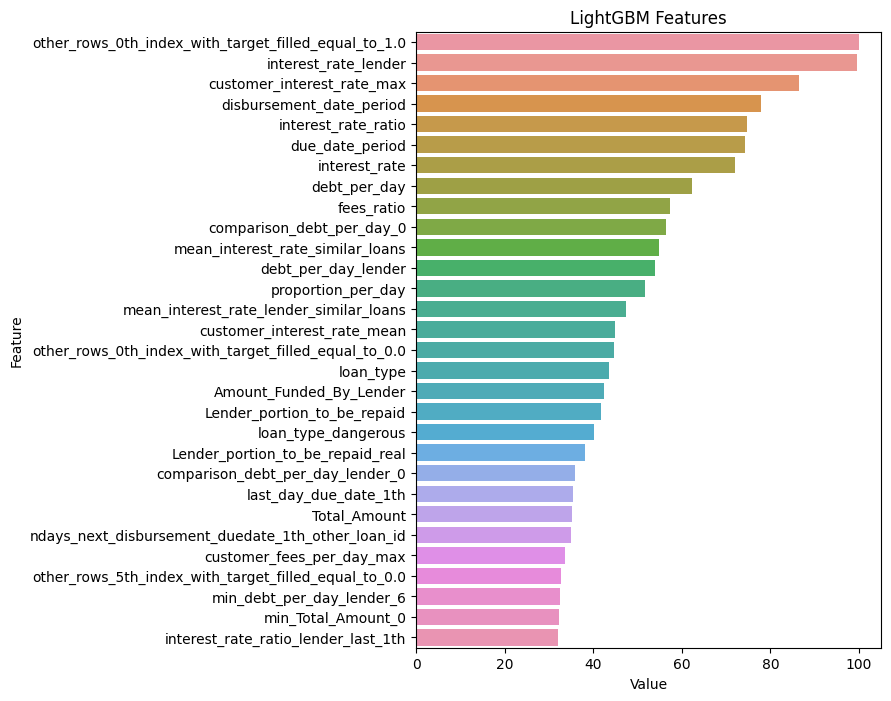

In [37]:
# Feature Importance
plt.figure(figsize=(6, 8))
sns.barplot(x="Value", y="Feature", data=Feature_Imp.head(30))
plt.title('LightGBM Features')
plt.show()

___
# **XGBoost**

In [38]:
# Model parameters
MODEL_PARAMS_xgb = [
                    {'objective': 'binary:logistic', 'verbosity': 0, 'boosting_type': 'gbdt', 'random_state': 12, 'n_estimators': 10000, 'early_stopping_rounds': 30, 'learning_rate': 0.037695471974398154, 'max_depth': 19, 'gamma': 0.2996373502443526, 'reg_alpha': 0.14818756699678315, 'min_child_weight': 0.26499279318451574, 'subsample': 0.9766213800725797, 'colsample_bytree': 0.5789902152406198, 'nthread': -1, 'tree_method': 'gpu_hist', 'gpu_id': 0},
                    {'objective': 'binary:logistic', 'verbosity': 0, 'boosting_type': 'gbdt', 'random_state': 12, 'n_estimators': 10000, 'early_stopping_rounds': 30, 'learning_rate': 0.06460773182610006, 'max_depth': 13, 'gamma': 0.34713416372150996, 'reg_alpha': 0.22262003945330788, 'min_child_weight': 0.203688665602608, 'subsample': 0.9485664627537648, 'colsample_bytree': 0.6963116832973049, 'nthread': -1, 'tree_method': 'gpu_hist', 'gpu_id': 0},
                    {'objective': 'binary:logistic', 'verbosity': 0, 'boosting_type': 'gbdt', 'random_state': 12, 'n_estimators': 10000, 'early_stopping_rounds': 30, 'learning_rate': 0.033877540924546284, 'max_depth': 14, 'gamma': 0.6969993219499027, 'reg_alpha': 0.33437442726321304, 'min_child_weight': 0.31388122477099595, 'subsample': 0.9239257073852377, 'colsample_bytree': 0.6253710558594304, 'nthread': -1, 'tree_method': 'gpu_hist', 'gpu_id': 0},
                    {'objective': 'binary:logistic', 'verbosity': 0, 'boosting_type': 'gbdt', 'random_state': 12, 'n_estimators': 10000, 'early_stopping_rounds': 30, 'learning_rate': 0.07248019116309042, 'max_depth': 11, 'gamma': 0.2253582016868308, 'reg_alpha': 0.28552770348457157, 'min_child_weight': 0.2862008023462035, 'subsample': 0.9604193795971736, 'colsample_bytree': 0.7347173306052908, 'nthread': -1, 'tree_method': 'gpu_hist', 'gpu_id': 0},
                    {'objective': 'binary:logistic', 'verbosity': 0, 'boosting_type': 'gbdt', 'random_state': 12, 'n_estimators': 10000, 'early_stopping_rounds': 30, 'learning_rate': 0.025472637359425877, 'max_depth': 17, 'gamma': 0.5703664294582016, 'reg_alpha': 0.2742648749653868, 'min_child_weight': 0.21650673479847138, 'subsample': 0.8789629868922165, 'colsample_bytree': 0.6212324677573643, 'nthread': -1, 'tree_method': 'gpu_hist', 'gpu_id': 0},
                    {'objective': 'binary:logistic', 'verbosity': 0, 'boosting_type': 'gbdt', 'random_state': 12, 'n_estimators': 10000, 'early_stopping_rounds': 30, 'learning_rate': 0.0370565788534241, 'max_depth': 19, 'gamma': 0.4423454635956159, 'reg_alpha': 0.013387213020264369, 'min_child_weight': 0.23121040768962753, 'subsample': 0.9602898786657329, 'colsample_bytree': 0.5466214232613026, 'nthread': -1, 'tree_method': 'gpu_hist', 'gpu_id': 0},
                    {'objective': 'binary:logistic', 'verbosity': 0, 'boosting_type': 'gbdt', 'random_state': 12, 'n_estimators': 10000, 'early_stopping_rounds': 30, 'learning_rate': 0.028959372862216705, 'max_depth': 22, 'gamma': 0.13180703950483266, 'reg_alpha': 0.15823124098845864, 'min_child_weight': 0.153759992092993, 'subsample': 0.9530939336261169, 'colsample_bytree': 0.6663288318304456, 'nthread': -1, 'tree_method': 'gpu_hist', 'gpu_id': 0},
                    ]

fit_params = {"eval_metric" : 'logloss',
              "verbose":False,
             }

len(MODEL_PARAMS)

6

In [39]:
%%time

# Prédictions
oof_preds_xgb  = np.zeros((len(MODEL_PARAMS_xgb), len(df)))
test_preds_xgb = np.zeros((len(MODEL_PARAMS_xgb), gkf.n_splits, len(df_test)))

# Training loop
for nth_model, clf_params in enumerate(MODEL_PARAMS_xgb):

    print()
    print("-"*50)
    print(f"MODEL n°{nth_model}.")

    # Training loop
    for fold, (train_index, test_index) in enumerate(gkf.split(df[feats], df['target'], groups=df['customer_id'])):

        # Create train and test data
        xtr, ytr = df.loc[train_index, feats], df.loc[train_index, 'target']
        xte, yte = df.loc[test_index, feats], df.loc[test_index, 'target']

        # Create model    
        model = xgb.XGBClassifier(**clf_params)
    
        # Fit model
        fit_params["eval_set"] = [(xte, yte)]
        model.fit(xtr,
                  ytr,
                  **fit_params,
                  )
    
        # Save model
        #joblib.dump(model, f"lgbm_fold{fold}.joblib")
    
        # Store oof predictions
        preds = model.predict_proba(xte)[:, 1]
        oof_preds_xgb[nth_model, test_index] = preds
    
        # Make predictions
        test_preds_xgb[nth_model, fold] = model.predict_proba(df_test[feats])[:, 1]
        
        # Print fold score
        score = round(f1_score(df.loc[test_index, 'target'], np.round(preds)), 3)
        print(f"Fold {fold} : score = {str(score).ljust(6)}")
                    
    # Print final score
    score = round(f1_score(df["target"], np.round(oof_preds_xgb[nth_model])), 4)
    print(f"\n=> Final score n°{nth_model} : score = {str(score).ljust(6)}\n")

# ----------------------------------------------------------------------------------------
# Mean over folds for test preds
test_preds_xgb = test_preds_xgb.mean(axis=1)


--------------------------------------------------
MODEL n°0.
Fold 0 : score = 0.905 
Fold 1 : score = 0.927 
Fold 2 : score = 0.926 
Fold 3 : score = 0.893 
Fold 4 : score = 0.913 
Fold 5 : score = 0.916 
Fold 6 : score = 0.889 

=> Final score n°0 : score = 0.9099


--------------------------------------------------
MODEL n°1.
Fold 0 : score = 0.903 
Fold 1 : score = 0.933 
Fold 2 : score = 0.923 
Fold 3 : score = 0.888 
Fold 4 : score = 0.916 
Fold 5 : score = 0.919 
Fold 6 : score = 0.889 

=> Final score n°1 : score = 0.9101


--------------------------------------------------
MODEL n°2.
Fold 0 : score = 0.903 
Fold 1 : score = 0.919 
Fold 2 : score = 0.917 
Fold 3 : score = 0.9   
Fold 4 : score = 0.905 
Fold 5 : score = 0.926 
Fold 6 : score = 0.889 

=> Final score n°2 : score = 0.908 


--------------------------------------------------
MODEL n°3.
Fold 0 : score = 0.911 
Fold 1 : score = 0.93  
Fold 2 : score = 0.917 
Fold 3 : score = 0.903 
Fold 4 : score = 0.916 
Fold 5 : s

___
___
# **Ensemble**

In [40]:
oof_ensemble = np.concatenate([oof_preds, oof_preds_xgb]).mean(axis=0)

# Model scores
print("LGBM")
for nth_model in range(len(MODEL_PARAMS)):
    score = round(f1_score(df["target"], np.round(oof_preds[nth_model])), 4)
    print(f"Model n°{nth_model} : score = {str(score).ljust(6)}")
score = round(f1_score(df["target"], np.round(oof_preds.mean(axis=0))), 4)
print(f"=> Ensemble : score = {str(score).ljust(6)}\n")

print("\nXGBOOST")
for nth_model in range(len(MODEL_PARAMS_xgb)):
    score = round(f1_score(df["target"], np.round(oof_preds_xgb[nth_model])), 4)
    print(f"Model n°{nth_model} : score = {str(score).ljust(6)}")
score = round(f1_score(df["target"], np.round(oof_preds_xgb.mean(axis=0))), 4)
print(f"=> Ensemble : score = {str(score).ljust(6)}\n")

# Ensemble
score = round(f1_score(df["target"], np.round(oof_ensemble)), 4)
print(f"\n=> Ensemble : score = {str(score).ljust(6)}\n")

LGBM
Model n°0 : score = 0.906 
Model n°1 : score = 0.9075
Model n°2 : score = 0.9092
Model n°3 : score = 0.9083
Model n°4 : score = 0.9115
Model n°5 : score = 0.9098
=> Ensemble : score = 0.9086


XGBOOST
Model n°0 : score = 0.9099
Model n°1 : score = 0.9101
Model n°2 : score = 0.908 
Model n°3 : score = 0.9141
Model n°4 : score = 0.9107
Model n°5 : score = 0.91  
Model n°6 : score = 0.9087
=> Ensemble : score = 0.9111


=> Ensemble : score = 0.9107



In [41]:
# Ensemble test preds
test_preds_ensemble = np.concatenate([test_preds, test_preds_xgb]).mean(axis=0)
test_preds_ensemble.shape

(18594,)

___
___
# **Submission**

In [42]:
# Create submission
df_test['Target'] = np.round(test_preds_ensemble)
sub = df_test[['ID', 'Target']]

# Export to CSV
sub.to_csv("submission_thr0.5.csv", index=False)

# Show
print(sub.shape)
sub['Target'].value_counts().to_frame()

(18594, 2)


,count
Target,
0.0,17971
1.0,623


___
## **Post_processing**

In [43]:
# Create submission
sub = df_test[['ID', 'Target']]

# Assign value "1" to all loans of type 3 (Ghana) that are the very last of each customer
mask_last_loan = (df_test['nth_loan_id'] >= df_test.groupby('customer_id')['nth_loan_id'].transform(max))
mask = (mask_last_loan & (df_test['loan_type']==3))

# ID corresponding to our criterions
list_id = df_test[mask]['ID'].unique()
print("Number of IDS :", len(list_id))
sub.loc[sub['ID'].isin(list_id), 'Target'] = 1

# Submit
sub.to_csv("submission_optimized.csv", index=False)
display(sub['Target'].value_counts().to_frame())

Number of IDS : 379


,count
Target,
0.0,17592
1.0,1002
